TASK 1: LOAD THE DATASET

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/train.csv')

In [36]:
# Print the first five rows
print("First five rows of the dataset:")
print(df.head())

First five rows of the dataset:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  S

In [37]:
# Print the data type of each column
print("\nColumn data types:")
print(df.dtypes)


Column data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [38]:
# Print the DataFrame shape
print("\nDataFrame shape:")
print(df.shape)


DataFrame shape:
(1460, 81)


Task 2: NULL VALUE ANALYSIS

In [39]:
# Calculate the number of missing values in every column
null_count = df.isnull().sum()

# Calculate the percentage of missing values in every column
null_percentage = (df.isnull().sum() / df.shape[0]) * 100

# Create a summary table for every column
null_summary = pd.DataFrame({
    'Missing_Count': null_count,
    'Missing_Percentage': null_percentage
})

print("Missing value analysis for every column:")
print(null_summary.to_string())

Missing value analysis for every column:
               Missing_Count  Missing_Percentage
Id                         0            0.000000
MSSubClass                 0            0.000000
MSZoning                   0            0.000000
LotFrontage              259           17.739726
LotArea                    0            0.000000
Street                     0            0.000000
Alley                   1369           93.767123
LotShape                   0            0.000000
LandContour                0            0.000000
Utilities                  0            0.000000
LotConfig                  0            0.000000
LandSlope                  0            0.000000
Neighborhood               0            0.000000
Condition1                 0            0.000000
Condition2                 0            0.000000
BldgType                   0            0.000000
HouseStyle                 0            0.000000
OverallQual                0            0.000000
OverallCond                0

In [40]:
# Identify columns with more than 20% missing values
high_null_columns = null_summary[
    null_summary['Missing_Percentage'] > 20
].sort_values(by='Missing_Percentage', ascending=False)

print("Columns with more than 20% missing values:")
print(high_null_columns)

Columns with more than 20% missing values:
             Missing_Count  Missing_Percentage
PoolQC                1453           99.520548
MiscFeature           1406           96.301370
Alley                 1369           93.767123
Fence                 1179           80.753425
MasVnrType             872           59.726027
FireplaceQu            690           47.260274


In [41]:
# Identify numeric columns with missing values below 20%
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns_to_impute = [
    col for col in numeric_columns
    if 0 < df[col].isnull().mean() * 100 < 20
]

print("Numeric columns with missing values below 20%:")
print(numeric_columns_to_impute)

Numeric columns with missing values below 20%:
['LotFrontage', 'MasVnrArea', 'GarageYrBlt']


In [42]:
# Fill missing values in eligible numeric columns using the median
for col in numeric_columns_to_impute:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

    print(f"{col}: filled missing values with median = {median_value}")

LotFrontage: filled missing values with median = 69.0
MasVnrArea: filled missing values with median = 0.0
GarageYrBlt: filled missing values with median = 1980.0


In [43]:
print("Remaining missing values in imputed numeric columns:")
print(df[numeric_columns_to_impute].isnull().sum())

Remaining missing values in imputed numeric columns:
LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64


Task 3: DUPLICATE DETECTION AND REMOVAL

In [44]:
# Store null percentages before duplicate removal
null_percentage_before = (df.isnull().sum() / df.shape[0]) * 100

In [45]:
# Count fully duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [46]:
# Store the number of rows before duplicate removal
rows_before = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Store the number of rows after duplicate removal
rows_after = df.shape[0]

# Calculate how many rows were removed
rows_removed = rows_before - rows_after

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Number of rows removed:", rows_removed)

Rows before duplicate removal: 1460
Rows after duplicate removal: 1460
Number of rows removed: 0


In [47]:
# Calculate null percentages after duplicate removal
null_percentage_after = (df.isnull().sum() / df.shape[0]) * 100

# Check whether any null percentage changed
null_percentage_changed = not null_percentage_before.equals(
    null_percentage_after
)

print("Did duplicate removal change any null percentage?")
print(null_percentage_changed)

Did duplicate removal change any null percentage?
False


 TASK 4: DATA TYPE CORRECTION


In [48]:
# Display original data types
print("Data types before conversion:")
print("MSSubClass:", df['MSSubClass'].dtype)
print("MSZoning:", df['MSZoning'].dtype)

# Measure total memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()

# Correct MSSubClass because its numeric values are category codes
df['MSSubClass'] = df['MSSubClass'].astype('category')

# Convert the repetitive string column MSZoning to category
df['MSZoning'] = df['MSZoning'].astype('category')

# Measure total memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

# Calculate memory reduction
memory_saved = memory_before - memory_after
memory_reduction_percentage = (memory_saved / memory_before) * 100

# Display corrected data types
print("\nData types after conversion:")
print("MSSubClass:", df['MSSubClass'].dtype)
print("MSZoning:", df['MSZoning'].dtype)

# Display memory comparison
print("\nMemory Usage Comparison")
print("-" * 40)
print(f"Before conversion : {memory_before:,} bytes")
print(f"After conversion  : {memory_after:,} bytes")
print(f"Memory saved      : {memory_saved:,} bytes")
print(f"Memory reduction  : {memory_reduction_percentage:.2f}%")

Data types before conversion:
MSSubClass: int64
MSZoning: object

Data types after conversion:
MSSubClass: category
MSZoning: category

Memory Usage Comparison
----------------------------------------
Before conversion : 3,600,842 bytes
After conversion  : 3,518,680 bytes
Memory saved      : 82,162 bytes
Memory reduction  : 2.28%


Task 5: DESCRIPTIVE STATISTICS AND SKEWNESS

In [49]:
#  Display descriptive statistics for all numeric columns
print("DESCRIPTIVE STATISTICS FOR ALL NUMERIC COLUMNS")
print("=" * 60)

print(df.describe())


# Identify all numeric columns
numeric_columns = df.select_dtypes(include='number').columns


# Compute skewness for each numeric column using df[col].skew()
skewness_results = {}

for col in numeric_columns:
    skewness_results[col] = df[col].skew()


# Convert the skewness results into a DataFrame
skewness_table = pd.DataFrame(
    list(skewness_results.items()),
    columns=['Column', 'Skewness']
)


# Calculate absolute skewness
skewness_table['Absolute_Skewness'] = (
    skewness_table['Skewness'].abs()
)


# Sort columns from highest to lowest absolute skewness
skewness_table = skewness_table.sort_values(
    by='Absolute_Skewness',
    ascending=False
).reset_index(drop=True)


# Print skewness results for every numeric column
print("\nSKEWNESS OF ALL NUMERIC COLUMNS")
print("=" * 60)

print(skewness_table.to_string(index=False))


#  Identify the column with the highest absolute skewness
most_skewed_column = skewness_table.loc[0, 'Column']
highest_skewness = skewness_table.loc[0, 'Skewness']
highest_absolute_skewness = skewness_table.loc[0, 'Absolute_Skewness']



print("\nCOLUMN WITH THE HIGHEST ABSOLUTE SKEWNESS")
print("=" * 60)

print("Column:", most_skewed_column)
print("Skewness:", highest_skewness)
print("Absolute Skewness:", highest_absolute_skewness)

DESCRIPTIVE STATISTICS FOR ALL NUMERIC COLUMNS
                Id  LotFrontage        LotArea  OverallQual  OverallCond  \
count  1460.000000  1460.000000    1460.000000  1460.000000  1460.000000   
mean    730.500000    69.863699   10516.828082     6.099315     5.575342   
std     421.610009    22.027677    9981.264932     1.382997     1.112799   
min       1.000000    21.000000    1300.000000     1.000000     1.000000   
25%     365.750000    60.000000    7553.500000     5.000000     5.000000   
50%     730.500000    69.000000    9478.500000     6.000000     5.000000   
75%    1095.250000    79.000000   11601.500000     7.000000     6.000000   
max    1460.000000   313.000000  215245.000000    10.000000     9.000000   

         YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1   BsmtFinSF2  ...  \
count  1460.000000   1460.000000  1460.000000  1460.000000  1460.000000  ...   
mean   1971.267808   1984.865753   103.117123   443.639726    46.549315  ...   
std      30.202904     20.64

Task 6: OUTLIER DETECTION USING IQR

In [50]:
# Numeric columns selected for IQR outlier analysis
outlier_columns = ['SalePrice', 'GrLivArea']

outlier_results = []

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_results.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count
    })

outlier_results_df = pd.DataFrame(outlier_results)

print("IQR Outlier Analysis:")
print(outlier_results_df.to_string(index=False))

IQR Outlier Analysis:
   Column       Q1        Q3      IQR  Lower_Bound  Upper_Bound  Outlier_Count
SalePrice 129975.0 214000.00 84025.00     3937.500   340037.500             61
GrLivArea   1129.5   1776.75   647.25      158.625     2747.625             31


Task 7: ALL FIVE REQUIRED VISUALIZATIONS

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder for required plot images
os.makedirs('outputs', exist_ok=True)

Plot 1: Line Plot

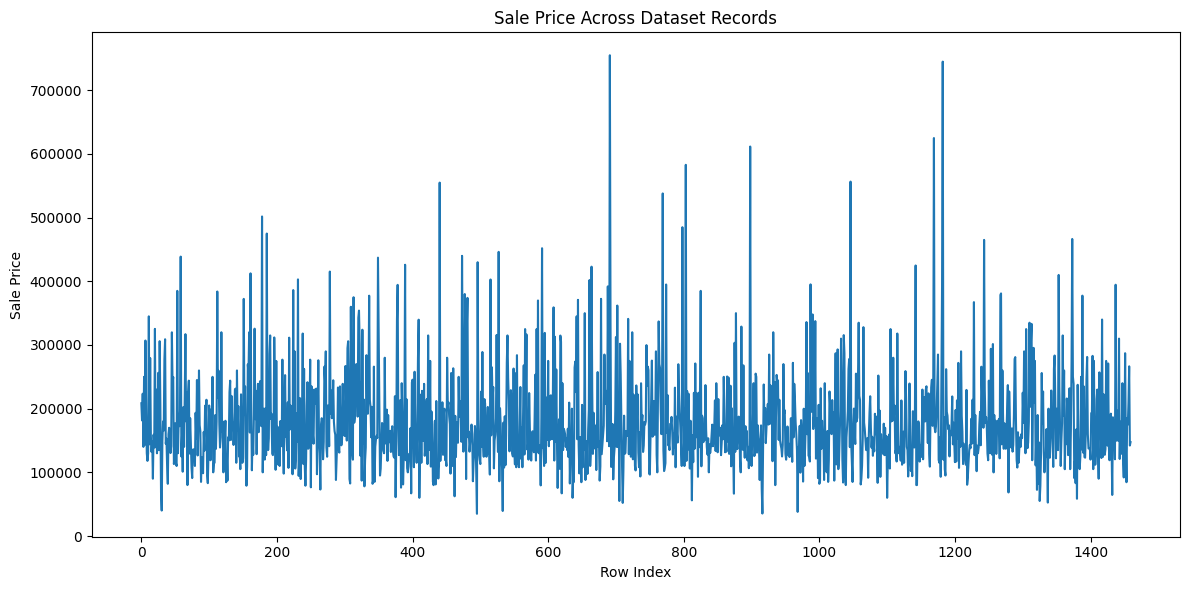

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['SalePrice'])

plt.title('Sale Price Across Dataset Records')
plt.xlabel('Row Index')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.savefig('outputs/line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Plot 2: Bar Chart

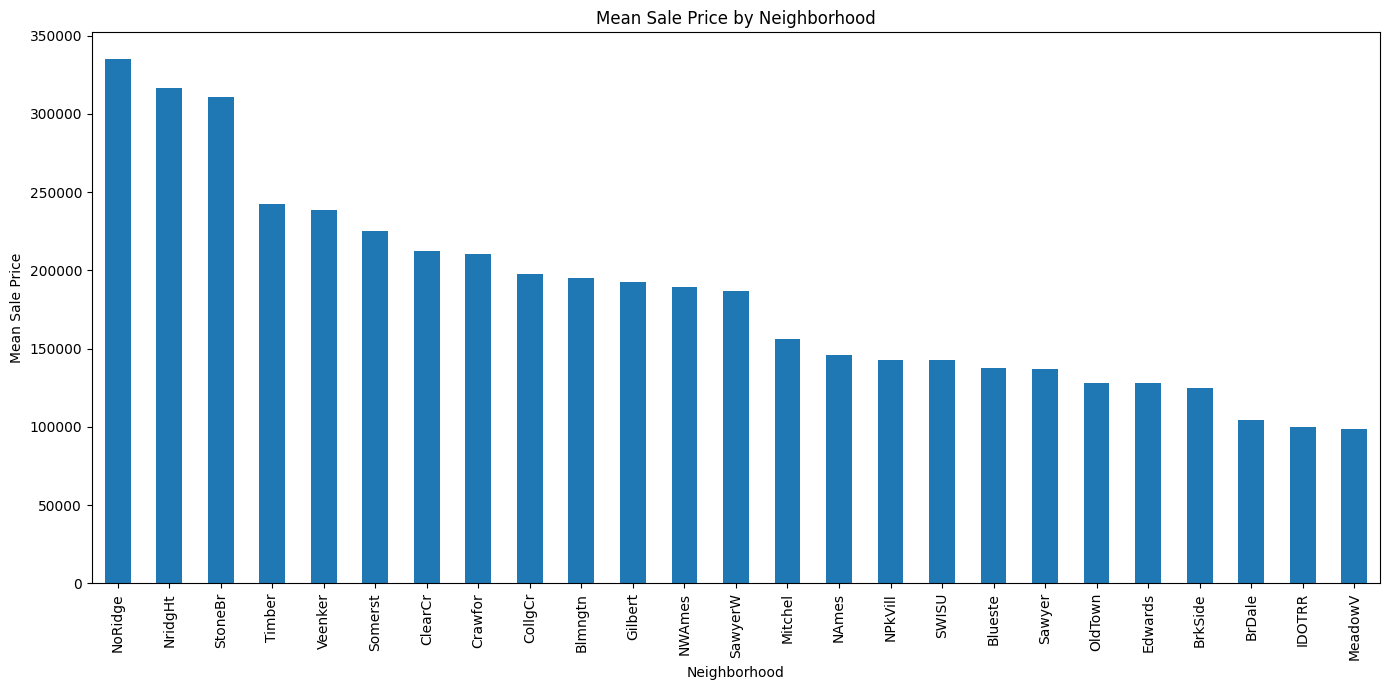

In [53]:
neighborhood_mean_price = (
    df.groupby('Neighborhood', observed=False)['SalePrice']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))

neighborhood_mean_price.plot(kind='bar')

plt.title('Mean Sale Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Mean Sale Price')
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('outputs/bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

Plot 3: Histogram of the Most Skewed Column

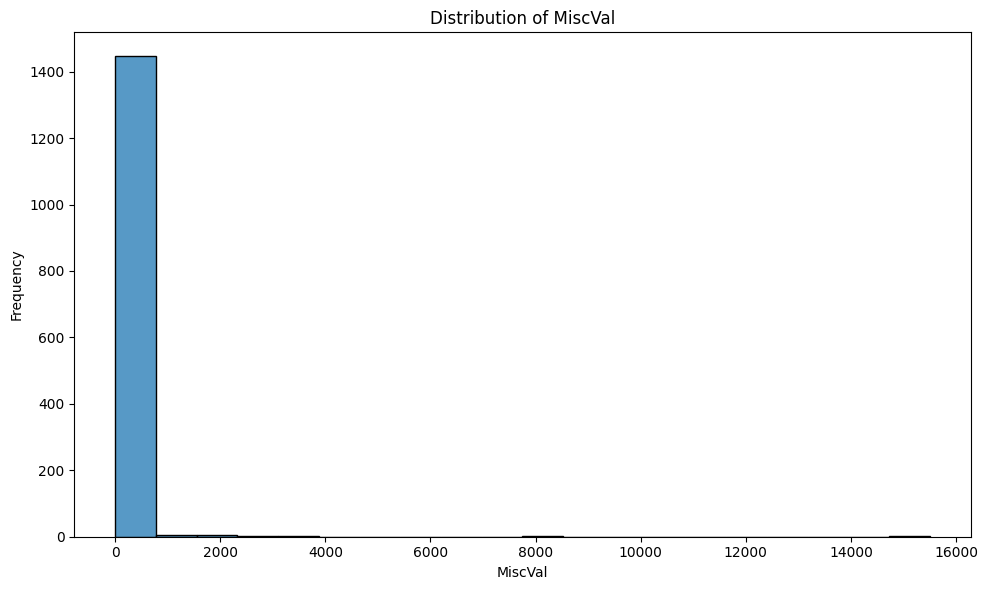

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x=most_skewed_column,
    bins=20
)

plt.title(f'Distribution of {most_skewed_column}')
plt.xlabel(most_skewed_column)
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/histogram.png', dpi=300, bbox_inches='tight')
plt.show()

Plot 4: Scatter Plot

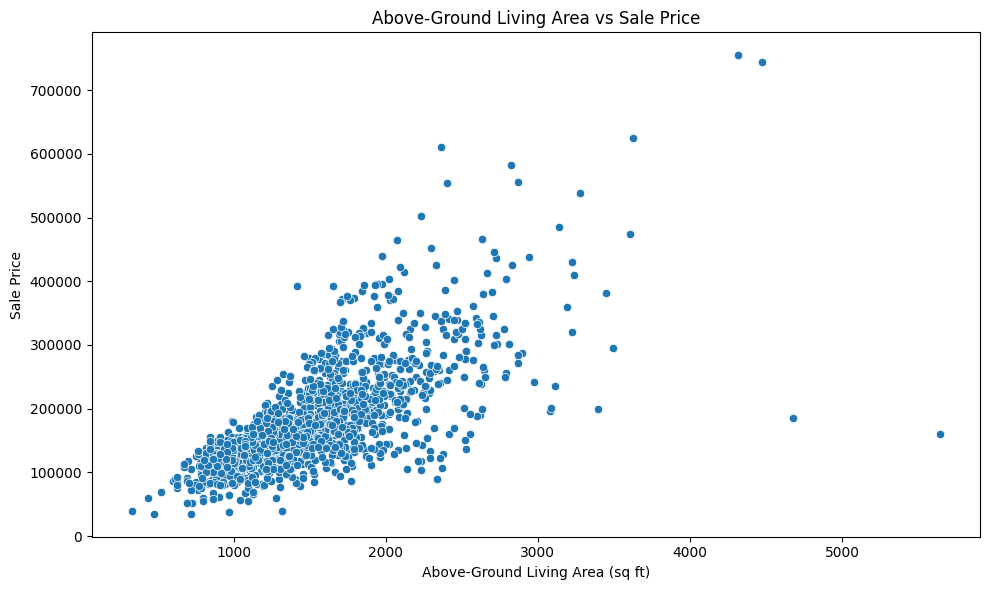

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='SalePrice'
)

plt.title('Above-Ground Living Area vs Sale Price')
plt.xlabel('Above-Ground Living Area (sq ft)')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.savefig('outputs/scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Plot 5: Box Plot

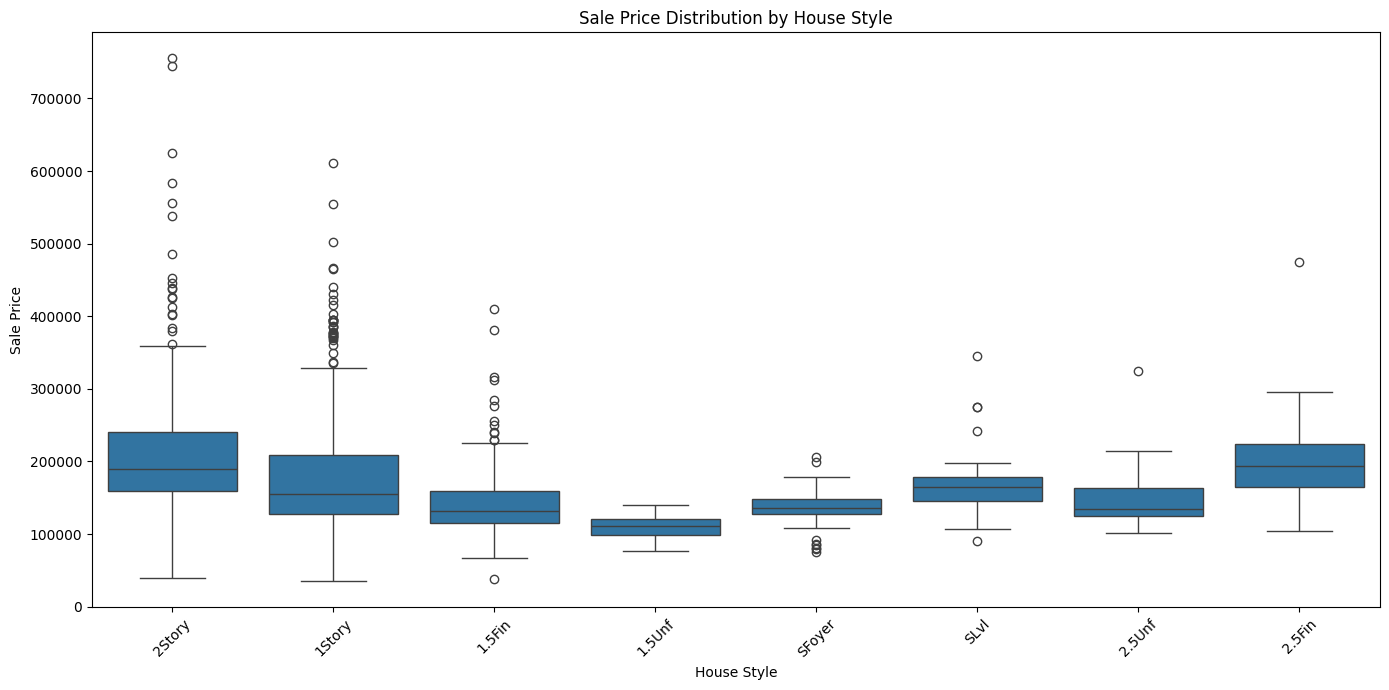

In [56]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x='HouseStyle',
    y='SalePrice'
)

plt.title('Sale Price Distribution by House Style')
plt.xlabel('House Style')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('outputs/box_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Task 8: CORRRELATION HEAT MAP

Pearson correlation matrix:
                     Id  LotFrontage   LotArea  OverallQual  OverallCond  \
Id             1.000000    -0.009921 -0.033226    -0.028365     0.012609   
LotFrontage   -0.009921     1.000000  0.304522     0.234812    -0.053281   
LotArea       -0.033226     0.304522  1.000000     0.105806    -0.005636   
OverallQual   -0.028365     0.234812  0.105806     1.000000    -0.091932   
OverallCond    0.012609    -0.053281 -0.005636    -0.091932     1.000000   
YearBuilt     -0.012713     0.116685  0.014228     0.572323    -0.375983   
YearRemodAdd  -0.021998     0.083348  0.013788     0.550684     0.073741   
MasVnrArea    -0.051071     0.178469  0.103321     0.407252    -0.125694   
BsmtFinSF1    -0.005024     0.214367  0.214103     0.239666    -0.046231   
BsmtFinSF2    -0.005968     0.042463  0.111170    -0.059119     0.040229   
BsmtUnfSF     -0.007940     0.124098 -0.002618     0.308159    -0.136841   
TotalBsmtSF   -0.015415     0.363472  0.260833     0.537808 

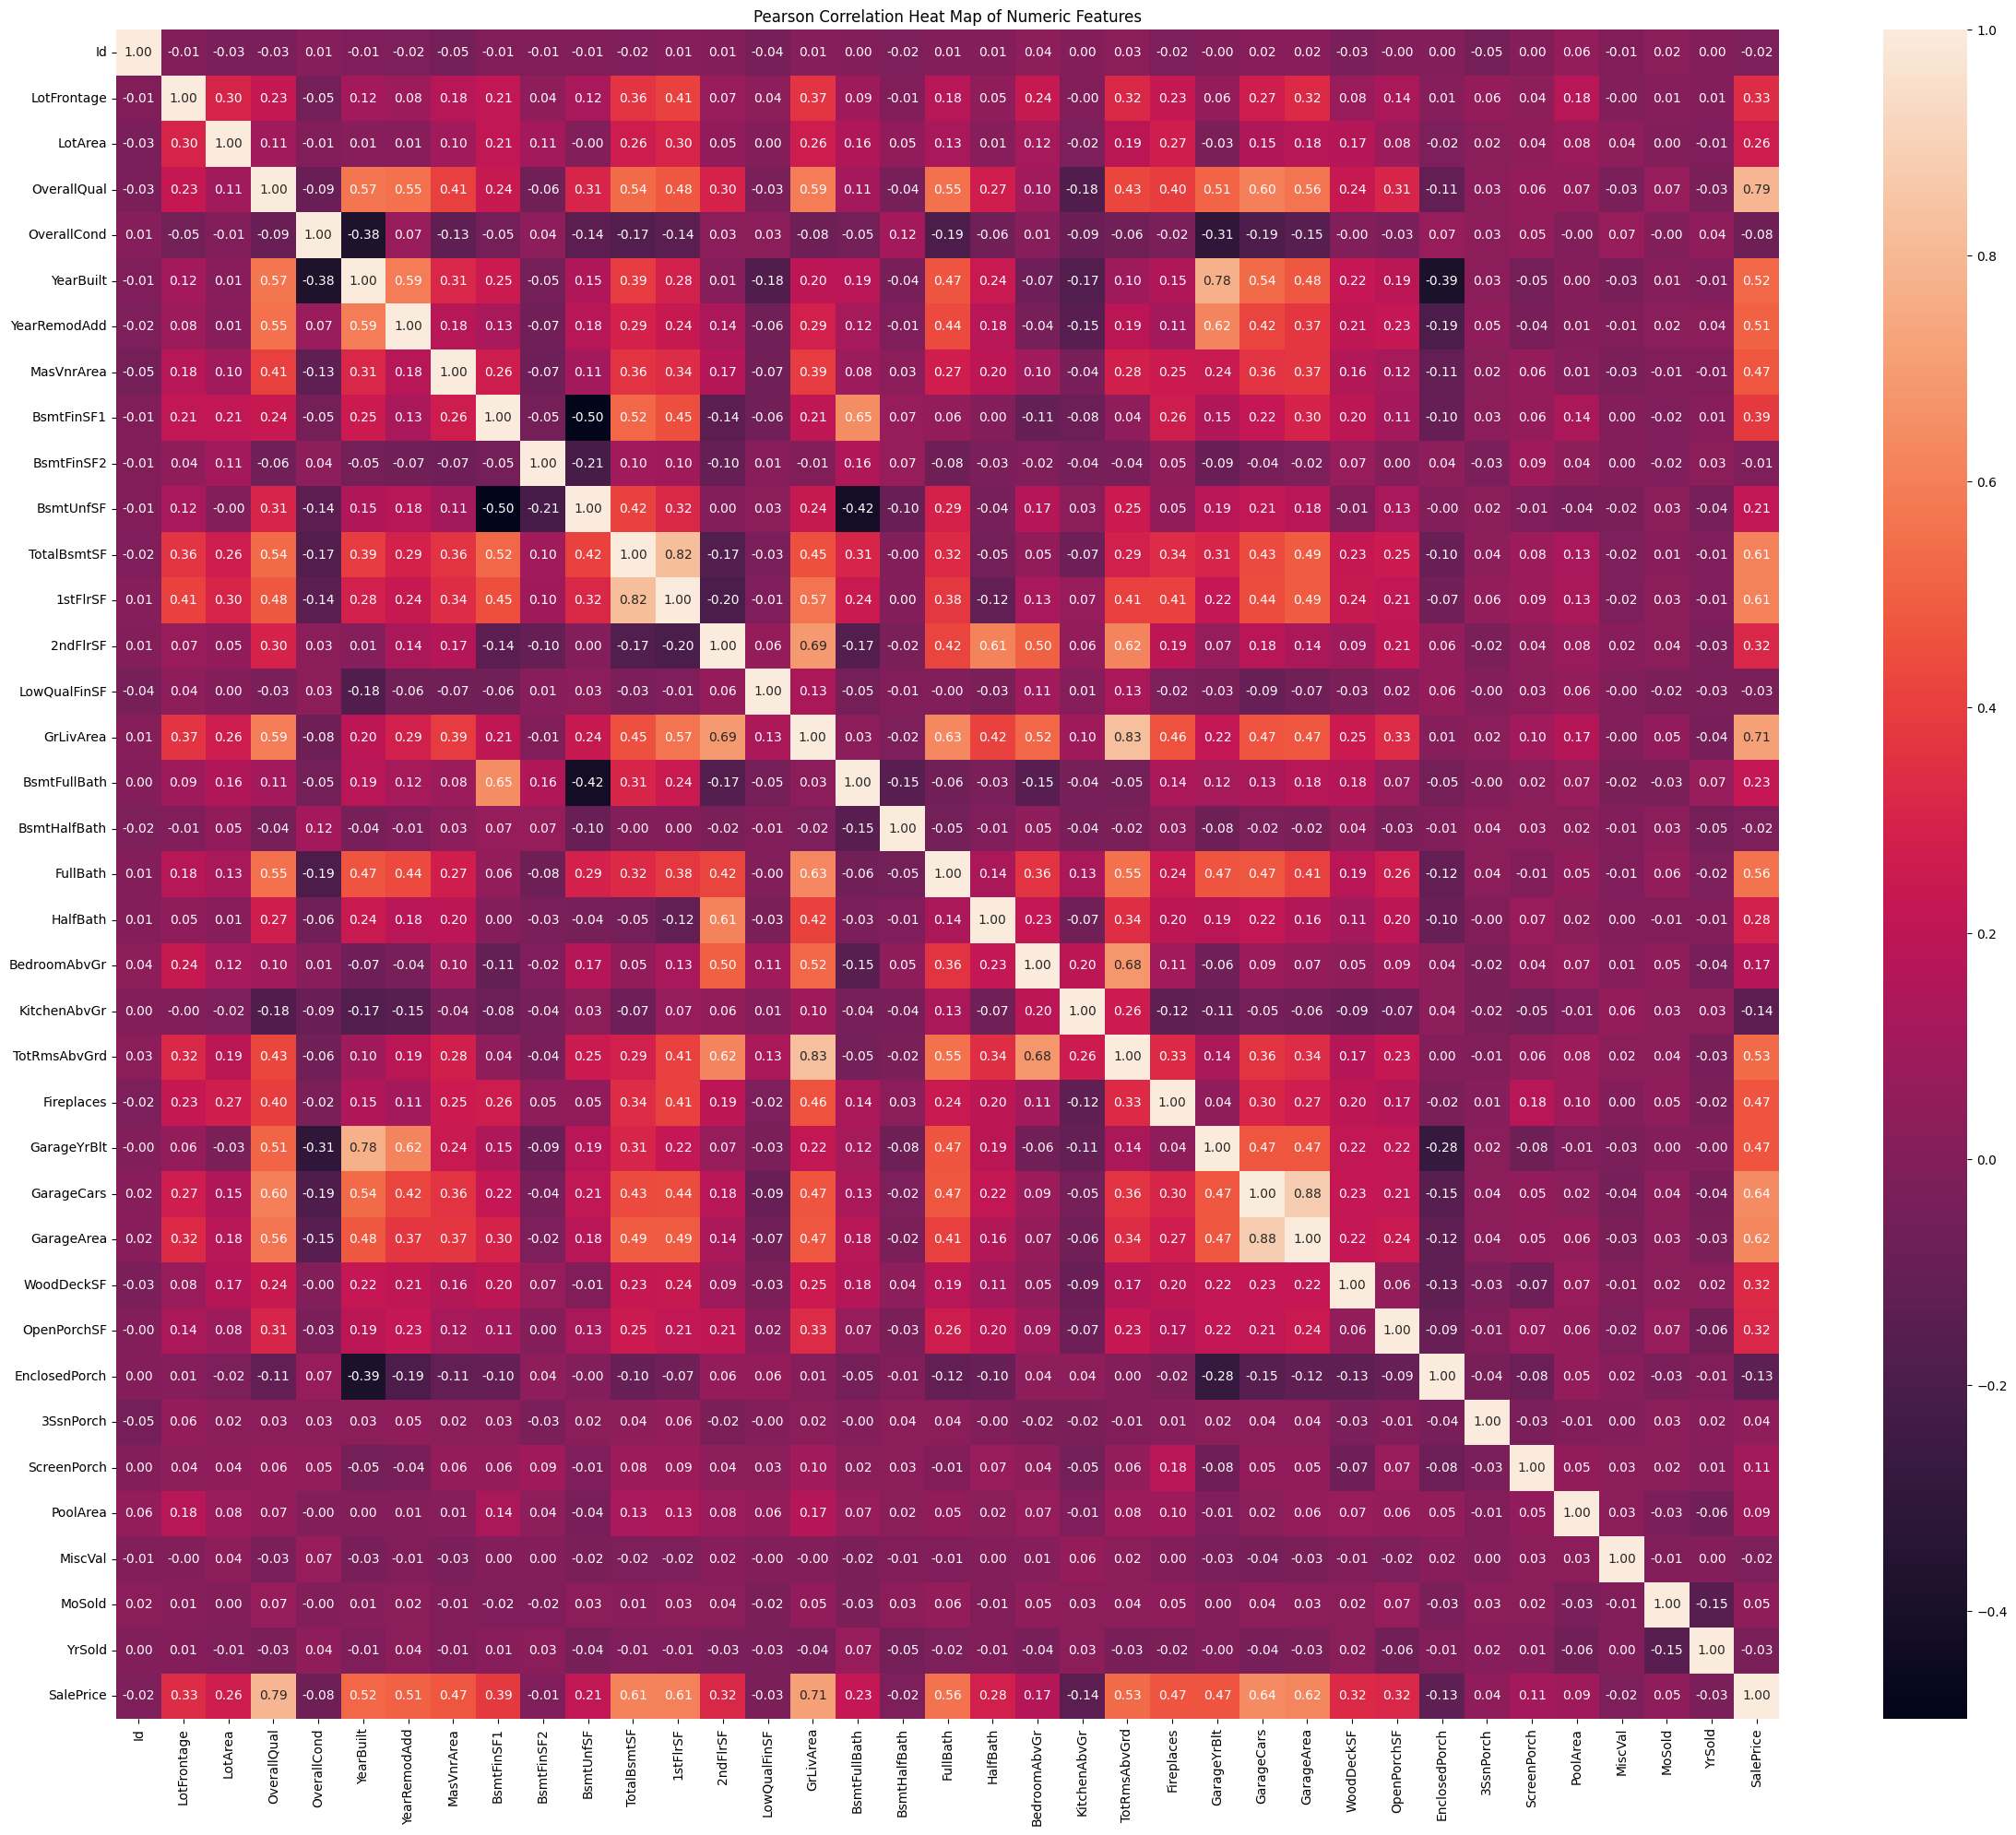

PAIR WITH THE HIGHEST ABSOLUTE CORRELATION
Variable 1: GarageCars
Variable 2: GarageArea
Correlation value: 0.882475414281462
Absolute correlation: 0.882475414281462


In [57]:
# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate Pearson correlation matrix
pearson_corr = numeric_df.corr()

print("Pearson correlation matrix:")
print(pearson_corr)

plt.figure(figsize=(24, 20))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f'
)

plt.title('Pearson Correlation Heat Map of Numeric Features')

plt.tight_layout()
plt.savefig(
    'outputs/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Remove self-correlations and duplicate pairs
upper_triangle = pearson_corr.where(
    np.triu(
        np.ones(pearson_corr.shape),
        k=1
    ).astype(bool)
)

highest_correlation_pair = (
    upper_triangle
    .abs()
    .stack()
    .idxmax()
)
variable_1 = highest_correlation_pair[0]
variable_2 = highest_correlation_pair[1]

highest_correlation_value = pearson_corr.loc[
    variable_1,
    variable_2
]
print("PAIR WITH THE HIGHEST ABSOLUTE CORRELATION")
print("=" * 60)
print("Variable 1:", variable_1)
print("Variable 2:", variable_2)
print("Correlation value:", highest_correlation_value)
print("Absolute correlation:", abs(highest_correlation_value))

Task 9 a: IMPUTATION STRATEGY COMPARISON

In [58]:
top_two_skewed_columns = (
    skewness_table
    .head(2)['Column']
    .tolist()
)

print("Two columns with the highest absolute skewness:")
print(top_two_skewed_columns)

imputation_comparison = []

for col in top_two_skewed_columns:
    mean_value = df[col].mean()
    median_value = df[col].median()
    skew_value = df[col].skew()

    imputation_comparison.append({
        'Column': col,
        'Skewness': skew_value,
        'Mean': mean_value,
        'Median': median_value
    })

imputation_comparison_df = pd.DataFrame(imputation_comparison)

print("\nMEAN AND MEDIAN COMPARISON")
print("=" * 60)
print(imputation_comparison_df.to_string(index=False))

for col in top_two_skewed_columns:
    df[col] = df[col].fillna(df[col].median())

print("\nNULL VALUES AFTER IMPUTATION")
print("=" * 60)
print(df[top_two_skewed_columns].isnull().sum())

Two columns with the highest absolute skewness:
['MiscVal', 'PoolArea']

MEAN AND MEDIAN COMPARISON
  Column  Skewness      Mean  Median
 MiscVal 24.476794 43.489041     0.0
PoolArea 14.828374  2.758904     0.0

NULL VALUES AFTER IMPUTATION
MiscVal     0
PoolArea    0
dtype: int64


Task 9 b: SPEARMAN RANK CORRELATION

In [59]:
numeric_df = df.select_dtypes(include='number')

pearson_corr = numeric_df.corr()

spearman_corr = numeric_df.corr(method='spearman')

print("SPEARMAN CORRELATION MATRIX")
print("=" * 60)
print(spearman_corr)

correlation_difference = (spearman_corr - pearson_corr).abs()

upper_triangle_difference = correlation_difference.where(
    np.triu(
        np.ones(correlation_difference.shape),
        k=1
    ).astype(bool)
)

top_three_pairs = (
    upper_triangle_difference
    .stack()
    .sort_values(ascending=False)
    .head(3)
)

difference_results = []

for (variable_1, variable_2), difference in top_three_pairs.items():
    pearson_value = pearson_corr.loc[variable_1, variable_2]
    spearman_value = spearman_corr.loc[variable_1, variable_2]

    if abs(spearman_value) > abs(pearson_value):
        relationship_type = "Monotonic but non-linear"
        preferred_measure = "Spearman"
    else:
        relationship_type = "Approximately linear"
        preferred_measure = "Pearson"

    difference_results.append({
        'Variable 1': variable_1,
        'Variable 2': variable_2,
        'Pearson': pearson_value,
        'Spearman': spearman_value,
        '|Spearman - Pearson|': difference,
        'Relationship': relationship_type,
        'Preferred Measure': preferred_measure
    })

difference_table = pd.DataFrame(difference_results)

print("\nTHREE PAIRS WITH THE LARGEST ABSOLUTE DIFFERENCE")
print("=" * 60)
print(difference_table.to_string(index=False))

SPEARMAN CORRELATION MATRIX
                     Id  LotFrontage   LotArea  OverallQual  OverallCond  \
Id             1.000000    -0.032951 -0.005364    -0.028771     0.003622   
LotFrontage   -0.032951     1.000000  0.554082     0.230305    -0.072772   
LotArea       -0.005364     0.554082  1.000000     0.233303    -0.046912   
OverallQual   -0.028771     0.230305  0.233303     1.000000    -0.177521   
OverallCond    0.003622    -0.072772 -0.046912    -0.177521     1.000000   
YearBuilt     -0.005130     0.185331  0.103385     0.647392    -0.416964   
YearRemodAdd  -0.011680     0.101659  0.075158     0.557723    -0.041464   
MasVnrArea    -0.036547     0.242800  0.175909     0.408136    -0.175895   
BsmtFinSF1    -0.013038     0.150312  0.171995     0.132957    -0.011087   
BsmtFinSF2    -0.006736     0.052350  0.072019    -0.117560     0.102471   
BsmtUnfSF     -0.009509     0.097988  0.077830     0.272939    -0.128270   
TotalBsmtSF   -0.033187     0.352150  0.366197     0.459915 

Task 9 c: GROUPED AGGREGATION

In [60]:
categorical_col = 'Neighborhood'
numeric_col = 'SalePrice'
grouped_stats = (
    df.groupby(categorical_col, observed=False)[numeric_col]
    .agg(['mean', 'std', 'count'])
    .sort_values(by='mean', ascending=False)
)

print("GROUPED STATISTICS BY NEIGHBORHOOD")
print("=" * 60)
print(grouped_stats)

highest_mean_group = grouped_stats['mean'].idxmax()
highest_mean_value = grouped_stats['mean'].max()

highest_std_group = grouped_stats['std'].idxmax()
highest_std_value = grouped_stats['std'].max()

highest_group_mean = grouped_stats['mean'].max()
lowest_group_mean = grouped_stats['mean'].min()

mean_ratio = highest_group_mean / lowest_group_mean

print("\nGROUP WITH THE HIGHEST MEAN")
print("=" * 60)
print("Neighborhood:", highest_mean_group)
print("Mean SalePrice:", highest_mean_value)

print("\nGROUP WITH THE HIGHEST STANDARD DEVIATION")
print("=" * 60)
print("Neighborhood:", highest_std_group)
print("Standard Deviation:", highest_std_value)

print("\nRATIO OF HIGHEST GROUP MEAN TO LOWEST GROUP MEAN")
print("=" * 60)
print("Highest group mean:", highest_group_mean)
print("Lowest group mean:", lowest_group_mean)
print("Ratio:", mean_ratio)

GROUPED STATISTICS BY NEIGHBORHOOD
                       mean            std  count
Neighborhood                                     
NoRidge       335295.317073  121412.658640     41
NridgHt       316270.623377   96392.544954     77
StoneBr       310499.000000  112969.676640     25
Timber        242247.447368   64845.651549     38
Veenker       238772.727273   72369.317959     11
Somerst       225379.837209   56177.555888     86
ClearCr       212565.428571   50231.538993     28
Crawfor       210624.725490   68866.395472     51
CollgCr       197965.773333   51403.666438    150
Blmngtn       194870.882353   30393.229219     17
Gilbert       192854.506329   35986.779085     79
NWAmes        189050.068493   37172.218106     73
SawyerW       186555.796610   55651.997820     59
Mitchel       156270.122449   36486.625334     49
NAmes         145847.080000   33075.345450    225
NPkVill       142694.444444    9377.314529      9
SWISU         142591.360000   32622.917679     25
Blueste       1

Task 10:SAVE THE CLEAN DATASET

In [61]:
# Save the cleaned dataset
df.to_csv('cleaned_data.csv', index=False)

print("Cleaned dataset saved successfully as cleaned_data.csv")

Cleaned dataset saved successfully as cleaned_data.csv


In [62]:
import os

print("File exists:", os.path.exists('cleaned_data.csv'))

cleaned_df = pd.read_csv('cleaned_data.csv')
print("Saved dataset shape:", cleaned_df.shape)

File exists: True
Saved dataset shape: (1460, 81)
